In [3]:
import scanpy as sc
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Batch-Corrected UMAP

In [19]:
adata = ad.read_h5ad("/ddn_exa/campbell/sli/methylcdm-project/data/training/methylation/pancancer_cohort_adata.h5ad")

In [20]:
sc.pp.pca(adata, n_comps=50, use_highly_variable=False)
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=50)
sc.tl.umap(adata, min_dist=0.3, spread=1.0, random_state=42)

cancer_types = adata.obs['project_id'].unique().tolist()

palette = {
    "TCGA-BLCA": "#E63946",   # red
    "TCGA-BRCA": "#457B9D",   # steel blue
    "TCGA-GBM":  "#2A9D8F",   # teal
    "TCGA-HNSC": "#E9C46A",   # amber
    "TCGA-KIRC": "#9B5DE5",   # purple
}

/home/campbell/sophiali/miniforge3/envs/methylcdm-env/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


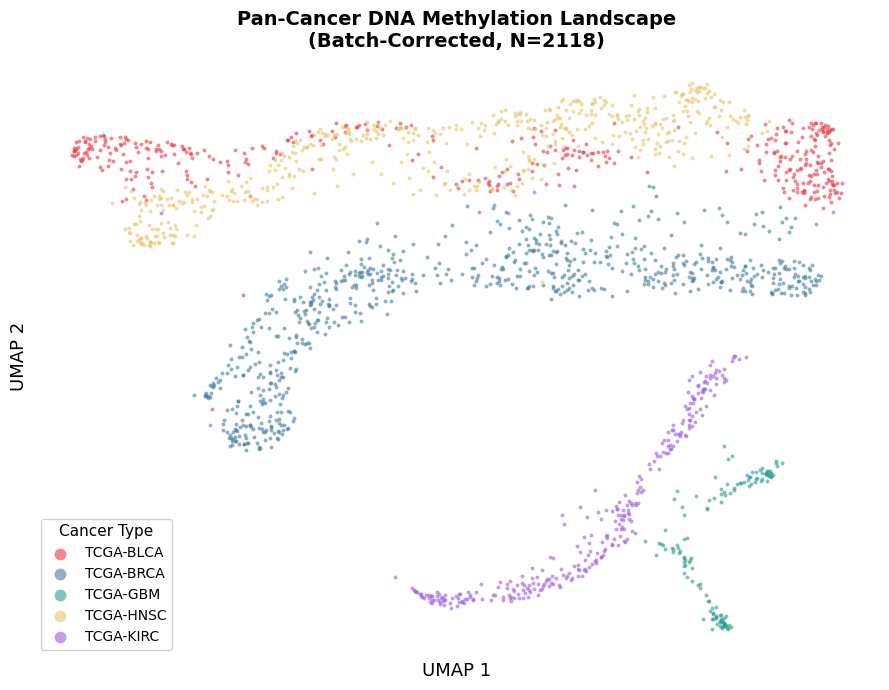

In [21]:
fig, ax = plt.subplots(figsize=(9, 7))

umap_coords = adata.obsm["X_umap"]

for cancer, color in palette.items():
    mask = adata.obs['project_id'] == cancer
    ax.scatter(
        umap_coords[mask, 0],
        umap_coords[mask, 1],
        c=color,
        label=cancer,
        s=8,           # point size — reduce if crowded
        alpha=0.6,
        linewidths=0,
        rasterized=True  # important for PDF export with many points
    )

ax.set_xlabel("UMAP 1", fontsize=13)
ax.set_ylabel("UMAP 2", fontsize=13)
ax.set_title("Pan-Cancer DNA Methylation Landscape\n(Batch-Corrected, N={})".format(
    adata.n_obs), fontsize=14, fontweight="bold")

ax.legend(
    title="Cancer Type",
    title_fontsize=11,
    fontsize=10,
    markerscale=3,
    framealpha=0.9,
    loc="best"
)

ax.set_xticks([])
ax.set_yticks([])
sns.despine(left=True, bottom=True)

plt.tight_layout()

# Save as both PNG (slides) and PDF (publication quality)
plt.savefig("pancancer_methylation_umap.png", dpi=300, bbox_inches="tight")
plt.savefig("pancancer_methylation_umap.pdf", bbox_inches="tight")
plt.show()

# Pre-Batch Correction

In [12]:
adatas = [
    ad.read_h5ad("/ddn_exa/campbell/sli/methylcdm-project/data/processed/methylation/TCGA-BLCA_adata.h5ad"),
    ad.read_h5ad("/ddn_exa/campbell/sli/methylcdm-project/data/processed/methylation/TCGA-BRCA_adata.h5ad"),
    ad.read_h5ad("/ddn_exa/campbell/sli/methylcdm-project/data/processed/methylation/TCGA-GBM_adata.h5ad"),
    ad.read_h5ad("/ddn_exa/campbell/sli/methylcdm-project/data/processed/methylation/TCGA-HNSC_adata.h5ad"),
    ad.read_h5ad("/ddn_exa/campbell/sli/methylcdm-project/data/processed/methylation/TCGA-KIRC_adata.h5ad"),
]

In [15]:
# Collect per-project .uns metadata
projects_uns = {}
for adata in adatas:

    project_name = adata.uns.get('project_id')
    project_metadata = {k: v for k, v in adata.uns.items() 
                        if k != 'project_id'}
    
    projects_uns[project_name] = project_metadata

# Concatenate projects, keeping the common set of CpG probes/genes
cohort_adata = ad.concat(
    adatas,
    join = "inner",
    label = "project_id",
    keys = [adata.uns['project_id'] for adata in adatas]
)

# Set the array type for annotation use as the highest resolution available
project_arrays = {
    name: meta.get('platform', None) 
    for name, meta in projects_uns.items()
}

cohort_adata.uns['platform'] = "Illumina 450K"
cohort_adata.uns['reference_genome'] = adatas[0].uns['reference_genome']
cohort_adata.uns['projects'] = projects_uns
cohort_adata.uns['data_type'] = adatas[0].uns['data_type']
cohort_adata.uns['conversion'] = adatas[0].uns['conversion']

In [16]:
adata = cohort_adata

/home/campbell/sophiali/miniforge3/envs/methylcdm-env/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


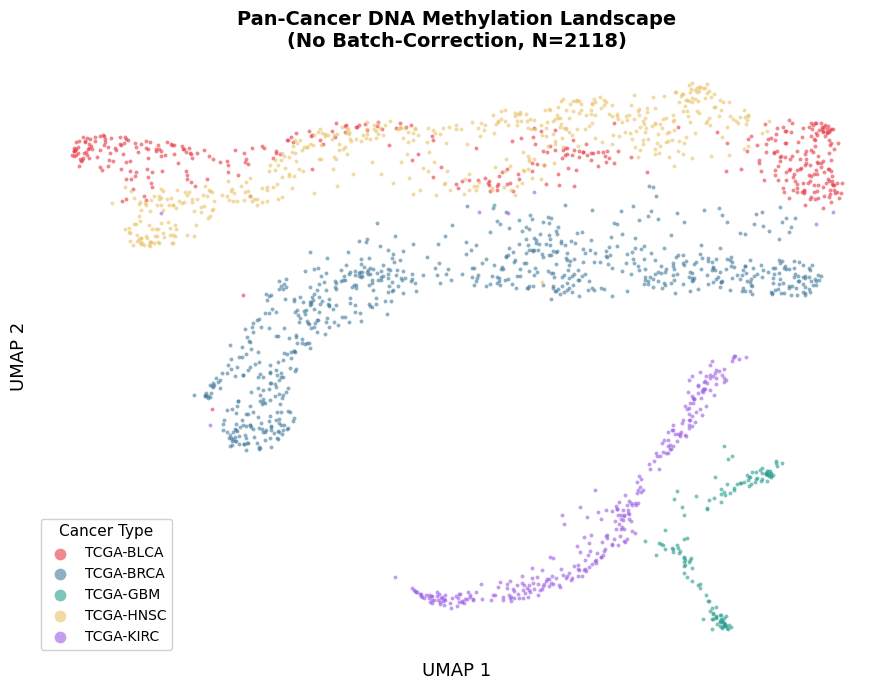

In [18]:
sc.pp.pca(adata, n_comps=50, use_highly_variable=False)
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=50)
sc.tl.umap(adata, min_dist=0.3, spread=1.0, random_state=42)

cancer_types = adata.obs['project_id'].unique().tolist()

palette = {
    "TCGA-BLCA": "#E63946",   # red
    "TCGA-BRCA": "#457B9D",   # steel blue
    "TCGA-GBM":  "#2A9D8F",   # teal
    "TCGA-HNSC": "#E9C46A",   # amber
    "TCGA-KIRC": "#9B5DE5",   # purple
}

fig, ax = plt.subplots(figsize=(9, 7))

umap_coords = adata.obsm["X_umap"]

for cancer, color in palette.items():
    mask = adata.obs['project_id'] == cancer
    ax.scatter(
        umap_coords[mask, 0],
        umap_coords[mask, 1],
        c=color,
        label=cancer,
        s=8,           # point size — reduce if crowded
        alpha=0.6,
        linewidths=0,
        rasterized=True  # important for PDF export with many points
    )

ax.set_xlabel("UMAP 1", fontsize=13)
ax.set_ylabel("UMAP 2", fontsize=13)
ax.set_title("Pan-Cancer DNA Methylation Landscape\n(No Batch-Correction, N={})".format(
    adata.n_obs), fontsize=14, fontweight="bold")

ax.legend(
    title="Cancer Type",
    title_fontsize=11,
    fontsize=10,
    markerscale=3,
    framealpha=0.9,
    loc="best"
)

ax.set_xticks([])
ax.set_yticks([])
sns.despine(left=True, bottom=True)

plt.tight_layout()

# Save as both PNG (slides) and PDF (publication quality)
plt.savefig("pancancer_umap_pre_batch_correction.png", dpi=300, bbox_inches="tight")
plt.show()